In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process.kernels import Matern

# ==== 1. Загрузка данных ====

In [36]:
fnames = [
    # '1_Drotleff_1993',
    '2_Bair_1973',
    # '3_Kellogg_1989',
    # '4_Febbraro_2020',
    # '5_Walton_1957',
    '6_Brandenburg_2023',
    '7_Sekharan_1967',
    # '8_Davids_1968',
    # '10_Prusachenko_2022',
    # '11_Gao_2022',
    # '100_Mohr'
]
# Пример структуры:
# XS (b), dXS (b), Ea (eV), dEa (eV)

dfs = []

# log leraning
# for name in fnames: 
#     temp = pd.read_csv(f'./full_data_corrected/{name}_corrected.csv')
#     temp["source"] = name

#     # ❗ важно: лог только для положительных значений
#     temp = temp[temp["XS (b)"] > 0]

#     # ==== ЛОГ-ПРЕОБРАЗОВАНИЕ ====
#     temp["log_XS"] = np.log(temp["XS (b)"])
#     temp["dlog_XS"] = temp["dXS (b)"] / temp["XS (b)"]

#     dfs.append(temp)

# linear leraning
for name in fnames: 
    temp = pd.read_csv(f'./full_data_corrected/{name}_corrected.csv')
    temp["source"] = name  # ← ОЧЕНЬ рекомендую
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# Переименуем для удобства
df = df.rename(columns={
    "XS (b)": "XS",
    "dXS (b)": "dXS",
    "Ea (eV)": "E",
    "dEa (eV)": "dE"
})

# ==== 2. Подготовка данных ====

In [37]:
X = df["E"].values.reshape(-1, 1)
y = df["XS"].values
y_err = df["dXS"].values

# X = df["E"].values.reshape(-1, 1)
# y = df["log_XS"].values
# y_err = df["dlog_XS"].values

# ==== 3. Ядро (kernel) ====

In [38]:
# RBF — гладкая зависимость
# WhiteKernel — шум
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1e5, length_scale_bounds=(1e2, 1e7)) \
         + WhiteKernel(noise_level=1e-10, noise_level_bounds=(1e-12, 1e-2))
# kernel = C(1.0) * Matern(length_scale=1e5, nu=1.5) + WhiteKernel()

# ==== 4. GPR модель ====

In [39]:
gpr = GaussianProcessRegressor(
    kernel=kernel,
    alpha=y_err**2,        # учитываем погрешности!
    n_restarts_optimizer=10,
    normalize_y=True
)

# ==== 5. Обучение ====

In [40]:
gpr.fit(X, y)

/Users/iv-gonch/work/alpha_n_stuff/13C_exp_xs_data/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(le...e_level=1e-10)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.","array([5.7600...shape=(1340,))"
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",10
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple 

# ==== 6. Предсказание на сетке ====

In [ ]:
E_min, E_max = X.min(), X.max()
X_pred = np.linspace(E_min, E_max, 10_000).reshape(-1, 1)

y_pred, y_std = gpr.predict(X_pred, return_std=True)

# y_pred_log, y_std = gpr.predict(X_pred, return_std=True)

# # обратно в обычные значения
# y_pred = np.exp(y_pred_log)

# # доверительный интервал (не просто exp!)
# y_upper = np.exp(y_pred_log + 2*y_std)
# y_lower = np.exp(y_pred_log - 2*y_std)

# ==== 7. График ====

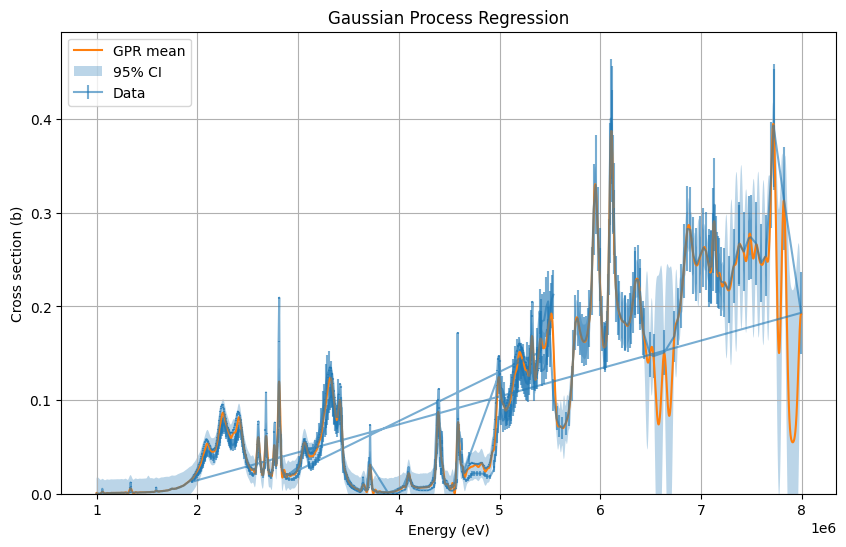

Optimized kernel: 1.21**2 * RBF(length_scale=2.6e+04) + WhiteKernel(noise_level=0.01)


In [44]:
plt.figure(figsize=(10, 6))

# Исходные точки
plt.errorbar(X.flatten(), y, yerr=y_err, 
            #  fmt='o', 
             label='Data', alpha=0.6)

# Среднее предсказание
plt.plot(X_pred, y_pred, label='GPR mean')

# Доверительный интервал (±2σ)
plt.fill_between(
    X_pred.flatten(),
    y_pred - 2*y_std,
    y_pred + 2*y_std,
    alpha=0.3,
    label='95% CI'
)

plt.xlabel("Energy (eV)")
plt.ylabel("Cross section (b)")
plt.title("Gaussian Process Regression")
plt.legend()
plt.grid()
plt.ylim(0)

plt.show()

# ======================================================================== #
# plt.figure(figsize=(10, 6))

# # исходные данные
# plt.errorbar(df["E"], df["XS"], yerr=df["dXS"], fmt='o', alpha=0.5)

# # предсказание
# plt.plot(X_pred, y_pred, label="GPR (log-space)")

# # доверительный интервал
# plt.fill_between(
#     X_pred.flatten(),
#     y_lower,
#     y_upper,
#     alpha=0.3
# )

# plt.xlabel("Energy (eV)")
# plt.ylabel("Cross section (b)")
# # plt.yscale("log")  # 🔥 очень желательно
# plt.legend()
# plt.grid()

# plt.show()

# ==== 8. Вывод ядра ====
print("Optimized kernel:", gpr.kernel_)